In [ ]:
import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from scipy.stats import pearsonr, spearmanr

eda

Ukuran dataset: (8380, 13)
Jumlah obat unik: 626

Distribusi karakteristik demand:
Karakteristik_Demand
Cenderung Intermittent    420
Cenderung Kontinu          50
Name: count, dtype: int64


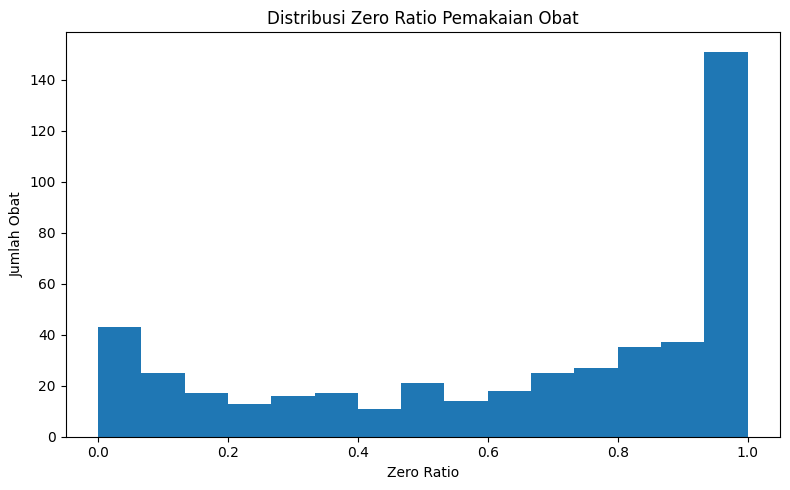

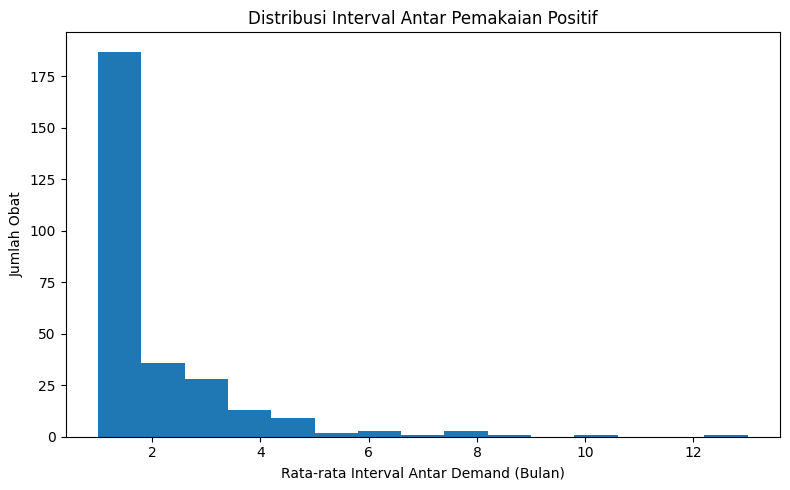

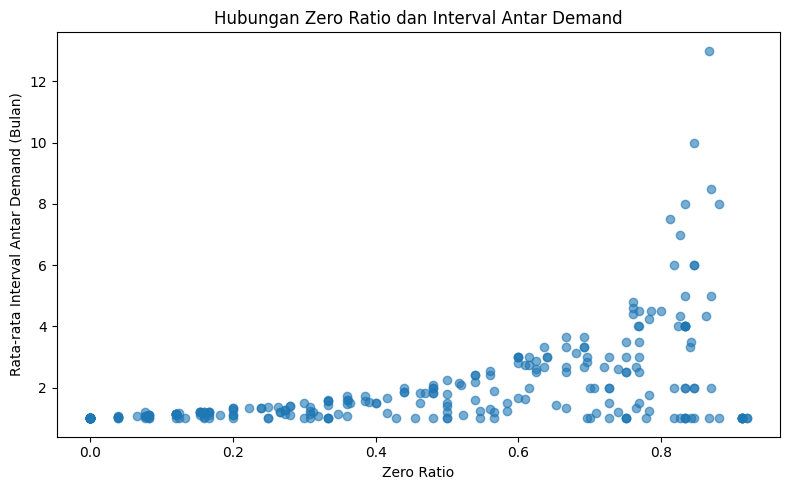


HASIL EDA INTERMITTENT DEMAND
Jumlah obat unik       : 470
Cenderung intermittent : 420 (89.36%)
Cenderung kontinu      : 50 (10.64%)
Rata-rata Zero Ratio   : 0.647
Median Zero Ratio      : 0.766
Rata-rata interval     : 1.944 bulan

File output:
EDA_Intermittent_Demand.xlsx


In [ ]:
# ============================================================
# CONFIG
# ============================================================
INPUT_PATH = "LPLPO CLEAN 2024-2026.xlsx"
SHEET_NAME = "Data_Lengkap"
OUT_EXCEL = "EDA_Intermittent_Demand.xlsx"

# Threshold untuk interpretasi sederhana
ZERO_RATIO_THRESHOLD = 0.40

# ============================================================
# 1. LOAD DATA
# ============================================================
def load_data(path=INPUT_PATH, sheet=SHEET_NAME) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=sheet)
    df["Periode"] = pd.to_datetime(
        df["Tahun"].astype(str) + "-" + df["Bulan"].astype(str).str.zfill(2),
        format="%Y-%m"
    )
    return df
df = load_data() 
print("Ukuran dataset:", df.shape)
print("Jumlah obat unik:", df[["Nama_Obat", "Satuan"]].drop_duplicates().shape[0])
# ============================================================
# 2. FUNGSI ANALISIS PER OBAT
# ============================================================
def analyze_intermittent(group):
    group = group.sort_values("Periode").copy()
    values = group["Pemakaian"].astype(float).values
    periods = group["Periode"].values
    n = len(values)
    # --------------------------------------------------------
    # A. ZERO RATIO
    # --------------------------------------------------------
    zero_count = np.sum(values == 0)
    positive_count = np.sum(values > 0)

    zero_ratio = zero_count / n if n > 0 else np.nan
    positive_ratio = positive_count / n if n > 0 else np.nan
    # --------------------------------------------------------
    # B. INTER-DEMAND INTERVAL
    # --------------------------------------------------------
    positive_indices = np.where(values > 0)[0]

    if len(positive_indices) >= 2:
        intervals = np.diff(positive_indices)
        avg_interval = np.mean(intervals)
        median_interval = np.median(intervals)
        max_interval = np.max(intervals)
    else:
        avg_interval = np.nan
        median_interval = np.nan
        max_interval = np.nan
    # --------------------------------------------------------
    # C. JUMLAH PERIODE DEMAND
    # --------------------------------------------------------
    demand_occurrences = len(positive_indices)
    # --------------------------------------------------------
    # D. ADAKAH POLA INTERMITTENT?
    # --------------------------------------------------------
    if (
        zero_ratio >= ZERO_RATIO_THRESHOLD
        or (
            not np.isnan(avg_interval)
            and avg_interval > 1
        )
    ):
        karakteristik = "Cenderung Intermittent"
    else:
        karakteristik = "Cenderung Kontinu"
    return pd.Series({
        "N_Bulan": n,
        "Jumlah_Demand_Positive": demand_occurrences,
        "Jumlah_Bulan_Nol": zero_count,
        "Zero_Ratio": zero_ratio,
        "Positive_Ratio": positive_ratio,
        "Rata2_Interval_Demand_Bulan": avg_interval,
        "Median_Interval_Demand_Bulan": median_interval,
        "Maks_Interval_Demand_Bulan": max_interval,
        "Karakteristik_Demand": karakteristik
    })
# ============================================================
# 3. ANALISIS SEMUA OBAT
# ============================================================
eda_obat = (
    df.groupby(
        ["Nama_Obat", "Satuan"],
        group_keys=False
    )
    .apply(analyze_intermittent)
    .reset_index()
)
print("\nDistribusi karakteristik demand:")
print(
    eda_obat["Karakteristik_Demand"]
    .value_counts()
)
# ============================================================
# 4. RINGKASAN DATASET
# ============================================================
jumlah_obat = eda_obat.shape[0]
jumlah_intermittent = (
    eda_obat["Karakteristik_Demand"]
    .eq("Cenderung Intermittent")
    .sum()
)
jumlah_kontinu = (
    eda_obat["Karakteristik_Demand"]
    .eq("Cenderung Kontinu")
    .sum()
)
ringkasan = pd.DataFrame({
    "Indikator": [
        "Jumlah baris dataset",
        "Jumlah kolom dataset",
        "Jumlah obat unik",
        "Jumlah obat cenderung intermittent",
        "Jumlah obat cenderung kontinu",
        "Persentase obat cenderung intermittent",
        "Rata-rata Zero Ratio",
        "Median Zero Ratio",
        "Rata-rata interval antar demand",
        "Median interval antar demand"
    ],
    "Nilai": [
        len(df),
        len(df.columns),
        jumlah_obat,
        jumlah_intermittent,
        jumlah_kontinu,
        jumlah_intermittent / jumlah_obat * 100,
        eda_obat["Zero_Ratio"].mean(),
        eda_obat["Zero_Ratio"].median(),
        eda_obat["Rata2_Interval_Demand_Bulan"].mean(),
        eda_obat["Median_Interval_Demand_Bulan"].median()
    ]
})
# ============================================================
# 5. DISTRIBUSI ZERO RATIO
# ============================================================
zero_ratio_summary = (
    eda_obat["Zero_Ratio"]
    .describe()
    .reset_index()
)
zero_ratio_summary.columns = [
    "Statistik",
    "Zero_Ratio"
]
# ============================================================
# 6. KELOMPOK ZERO RATIO
# ============================================================
def kategori_zero_ratio(x):
    if x == 0:
        return "Tidak ada nol"
    elif x < 0.25:
        return "<25%"
    elif x < 0.50:
        return "25%-<50%"
    elif x < 0.75:
        return "50%-<75%"
    else:
        return ">=75%"

eda_obat["Kategori_Zero_Ratio"] = (
    eda_obat["Zero_Ratio"]
    .apply(kategori_zero_ratio)
)
distribusi_zero = (
    eda_obat
    .groupby("Kategori_Zero_Ratio")
    .size()
    .reset_index(name="Jumlah_Obat")
)
distribusi_zero["Persentase"] = (
    distribusi_zero["Jumlah_Obat"]
    / jumlah_obat * 100
)
# ============================================================
# 7. INTERVAL DEMAND
# ============================================================
interval_summary = (
    eda_obat[
        "Rata2_Interval_Demand_Bulan"
    ]
    .describe()
    .reset_index()
)
interval_summary.columns = [
    "Statistik",
    "Interval_Demand_Bulan"
]
# ============================================================
# 8. SIMPAN KE EXCEL
# ============================================================
with pd.ExcelWriter(
    OUT_EXCEL,
    engine="openpyxl"
) as writer:
    ringkasan.to_excel(
        writer,
        sheet_name="Ringkasan",
        index=False
    )
    eda_obat.to_excel(
        writer,
        sheet_name="EDA_Per_Obat",
        index=False
    )
    distribusi_zero.to_excel(
        writer,
        sheet_name="Distribusi_Zero",
        index=False
    )
    zero_ratio_summary.to_excel(
        writer,
        sheet_name="Statistik_Zero",
        index=False
    )
    interval_summary.to_excel(
        writer,
        sheet_name="Statistik_Interval",
        index=False
    )
# ============================================================
# 9. GRAFIK 1 — DISTRIBUSI ZERO RATIO
# ============================================================
plt.figure(figsize=(8, 5))
plt.hist(
    eda_obat["Zero_Ratio"].dropna(),
    bins=15
)
plt.xlabel("Zero Ratio")
plt.ylabel("Jumlah Obat")
plt.title("Distribusi Zero Ratio Pemakaian Obat")
plt.tight_layout()
plt.savefig(
    "EDA_Distribusi_Zero_Ratio.png",
    dpi=300
)
plt.show()
# ============================================================
# 10. GRAFIK 2 — INTERVAL ANTAR DEMAND
# ============================================================
plt.figure(figsize=(8, 5))
plt.hist(
    eda_obat[
        "Rata2_Interval_Demand_Bulan"
    ].dropna(),
    bins=15
)
plt.xlabel(
    "Rata-rata Interval Antar Demand (Bulan)"
)
plt.ylabel("Jumlah Obat")
plt.title(
    "Distribusi Interval Antar Pemakaian Positif"
)
plt.tight_layout()
plt.savefig(
    "EDA_Interval_Demand.png",
    dpi=300
)
plt.show()
# ============================================================
# 11. GRAFIK 3 — ZERO RATIO VS INTERVAL DEMAND
# ============================================================
plt.figure(figsize=(8, 5))
plt.scatter(
    eda_obat["Zero_Ratio"],
    eda_obat["Rata2_Interval_Demand_Bulan"],
    alpha=0.6
)
plt.xlabel("Zero Ratio")
plt.ylabel(
    "Rata-rata Interval Antar Demand (Bulan)"
)
plt.title(
    "Hubungan Zero Ratio dan Interval Antar Demand"
)
plt.tight_layout()
plt.savefig(
    "EDA_ZeroRatio_vs_Interval.png",
    dpi=300
)
plt.show()
# ============================================================
# 12. OUTPUT UTAMA
# ============================================================
print("\n============================================")
print("HASIL EDA INTERMITTENT DEMAND")
print("============================================")
print(f"Jumlah obat unik       : {jumlah_obat}")
print(
    f"Cenderung intermittent : "
    f"{jumlah_intermittent} "
    f"({jumlah_intermittent / jumlah_obat * 100:.2f}%)"
)
print(
    f"Cenderung kontinu      : "
    f"{jumlah_kontinu} "
    f"({jumlah_kontinu / jumlah_obat * 100:.2f}%)"
)
print(
    f"Rata-rata Zero Ratio   : "
    f"{eda_obat['Zero_Ratio'].mean():.3f}"
)
print(
    f"Median Zero Ratio      : "
    f"{eda_obat['Zero_Ratio'].median():.3f}"
)

print(
    f"Rata-rata interval     : "
    f"{eda_obat['Rata2_Interval_Demand_Bulan'].mean():.3f} bulan"
)

print("\nFile output:")
print(OUT_EXCEL)

preprocessing 

In [3]:
# ============================= CONFIG ======================================
INPUT_PATH = "LPLPO CLEAN 2024-2026.xlsx"
SHEET_NAME = "Data_Lengkap"

OUT_TIMESERIES = "master_timeseries.csv"
OUT_MASTERLIST = "obat_master_list.xlsx"
OUT_LOG = "preprocessing_log.xlsx"

MISSING_REPORT_MONTH = "2025-04"   # bulan yang diketahui tidak pernah dilaporkan
FILL_MISSING_AS_ZERO = True        # lihat poin 5 di atas
# ============================================================================


def load_data(path=INPUT_PATH, sheet=SHEET_NAME) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=sheet)
    df["Periode"] = pd.to_datetime(
        df["Tahun"].astype(str) + "-" + df["Bulan"].astype(str).str.zfill(2),
        format="%Y-%m"
    )
    return df


def drop_exact_duplicates(df: pd.DataFrame):
    before = len(df)
    df = df.drop_duplicates()
    n_dropped = before - len(df)
    log = pd.DataFrame({"Jumlah_Baris_Duplikat_Dihapus": [n_dropped]})
    return df, log


def reconcile_satuan(df: pd.DataFrame):
    """Kembalikan df dgn kolom Satuan_Final + log konflik (lihat docstring atas)."""
    non_null_map = (
        df.dropna(subset=["Satuan"])
        .groupby("Nama_Obat")["Satuan"]
        .unique()
        .apply(list)
    )

    conflict_rows = []
    satuan_final = []

    for _, row in df.iterrows():
        nama = row["Nama_Obat"]
        satuan = row["Satuan"]
        options = non_null_map.get(nama, [])

        if pd.notna(satuan):
            satuan_final.append(satuan)
        elif len(options) == 1:
            satuan_final.append(options[0])          # Kasus A: auto-isi
        elif len(options) > 1:
            satuan_final.append("Tidak Diketahui")    # Kasus B: konflik, tandai
        else:
            satuan_final.append("Tidak Diketahui")

    df = df.copy()
    df["Satuan_Final"] = satuan_final

    conflict_names = [n for n, opts in non_null_map.items() if len(opts) > 1]
    for nama in conflict_names:
        opts = non_null_map[nama]
        total_per_satuan = (
            df[df["Nama_Obat"] == nama]
            .groupby("Satuan")["Pemakaian"].sum()
        )
        for s in opts:
            conflict_rows.append({
                "Nama_Obat": nama,
                "Satuan": s,
                "Total_Pemakaian_Satuan_Ini": total_per_satuan.get(s, 0)
            })

    conflict_log = pd.DataFrame(conflict_rows)
    return df, conflict_log


def clip_negative(df: pd.DataFrame):
    neg_mask = df["Pemakaian"] < 0
    log_negative = df.loc[neg_mask, ["Nama_Obat", "Satuan_Final", "Periode", "Pemakaian"]].copy()
    log_negative = log_negative.rename(columns={"Pemakaian": "Nilai_Asli_Sebelum_Clip"})
    df = df.copy()
    df.loc[neg_mask, "Pemakaian"] = 0
    return df, log_negative


def aggregate_monthly(df: pd.DataFrame) -> pd.DataFrame:
    """Jumlahkan Pemakaian per (Nama_Obat, Satuan_Final, Periode) -
    berjaga-jaga kalau masih ada >1 baris utk kombinasi yg sama."""
    agg = (
        df.groupby(["Nama_Obat", "Satuan_Final", "Periode"])["Pemakaian"]
        .sum()
        .reset_index()
        .rename(columns={"Satuan_Final": "Satuan"})
    )
    return agg


def build_full_grid(agg: pd.DataFrame) -> pd.DataFrame:
    """Buat grid lengkap semua obat x semua bulan (termasuk April 2025 sbg NaN),
    isi kombinasi yang tidak pernah dilaporkan sesuai FILL_MISSING_AS_ZERO."""
    all_periods = pd.date_range(
        agg["Periode"].min(), agg["Periode"].max(), freq="MS"
    )
    obat_keys = agg[["Nama_Obat", "Satuan"]].drop_duplicates()

    full_index = obat_keys.merge(
        pd.DataFrame({"Periode": all_periods}), how="cross"
    )
    full = full_index.merge(agg, on=["Nama_Obat", "Satuan", "Periode"], how="left")
    full["Ada_Laporan"] = full["Pemakaian"].notna()   # True = benar2 ada baris di Data_Lengkap

    missing_month = pd.Timestamp(MISSING_REPORT_MONTH)
    full["Is_Imputed"] = full["Periode"].eq(missing_month) & full["Pemakaian"].isna()

    if FILL_MISSING_AS_ZERO:
        not_the_gap_month = ~full["Periode"].eq(missing_month)
        full.loc[not_the_gap_month & full["Pemakaian"].isna(), "Pemakaian"] = 0

    full = full.sort_values(["Nama_Obat", "Satuan", "Periode"]).reset_index(drop=True)
    full["Pemakaian"] = (
        full.groupby(["Nama_Obat", "Satuan"])["Pemakaian"]
        .transform(lambda s: s.interpolate(method="linear", limit_direction="both"))
    )
    full["Pemakaian"] = full["Pemakaian"].round().astype(int)
    return full


def build_master_list(full: pd.DataFrame) -> pd.DataFrame:
    summary = (
        full.groupby(["Nama_Obat", "Satuan"])["Pemakaian"]
        .sum()
        .reset_index()
        .rename(columns={"Pemakaian": "Total_Pemakaian_2024_2026"})
        .sort_values("Total_Pemakaian_2024_2026", ascending=False)
        .reset_index(drop=True)
    )
    summary.insert(0, "No", range(1, len(summary) + 1))
    summary["Exclude (isi YES jika BUKAN obat konsumsi masyarakat)"] = ""
    return summary


def run():
    raw = load_data()
    raw, log_dup = drop_exact_duplicates(raw)
    raw, log_conflict = reconcile_satuan(raw)
    raw, log_negative = clip_negative(raw)

    # ==========================================================
    # HAPUS ITEM YANG BUKAN OBAT PASIEN
    # ==========================================================

    REMOVE_ITEMS = {
        "Kondom",
        "Rifapentin 300mg + INH 300 mg (@36)",
        "TLD",
        "TLE",
        "Isoniazid (INH) 300 mg",
        "OAT Anak",
        "OAT FDC / OAT Kat I",
        "OAT Kategori Harian",
        "Rifampisin 75 mg + INH 50 mg (3HR)",
        "Rifapentin 150 mg lepasan @240",
        "Rifapentin 300 mg + INH 300 mg (3HP) @36",

        "Alkacide",
        "Alkazyme",
        "Alkohol Swab",
        "Cardio (ECG) Gel",
        "Cat - gut chromic 2/0",
        "Cat - gut chromic 3/0",
        "Cat - gut optime 2/0",
        "Cat - gut optime 3/0",
        "Cuticel/Lomatul",
        "Etanol 70 %",
        "Folley Catheter 16",
        "Folley Catheter 18",
        "Folley Catheter 2 way no 20",

        "Abate",
        "Anti HBS Rapid Test",
        "Antigen deep blue",
        "Aquades 1000 ml",
        "Aquades infusan",
        "Asam asetat 5 %",
        "Biosciences Rapid 7 Parameter Narkoba",
        "Blood Lancet",
        "Box Object Glass",
        "Cell dyn 18 plus control",
        "Cell dyn emeral cleaner (abbot)",
        "Cell dyn emeral diluet",
        "Cell dyn emeral free lyse",
        "Cholesterol FS",
        "Cholesterol HDL 5x20 ml + 1x25 ml",
        "Cholesterol LDL-C Direct FC",
        "Citest Multi Drag (7 parameter)",
        "Cotton Swab Steril Jumbo",
        "Creatinin FS",
        "Diagnostar HIV 1/2",
        "Eter alkohol",
        "FOB (Fecal Occult Blood) Rapid Test",
        "Glucose / gula",
        "Golda",
        "HbsAg Strip",
        "Hemoglobin",
        "Holder Prontho",
        "Larutan eosin 2%",
        "Larutan fauchet",
        "Larutan KOH 10%",
        "Larutan rees ecker",
        "Larutan rhesus",
        "Larutan turk",
        "Multidrug Rapid 6 Parameter Narkoba",
        "Obyek Glass",
        "Oil imersion",
        "One clean",
        "Pewarna giemsa",
        "Pewarna gram",
        "Plesterin bulat",
        "Pot Dahak (Sputum Pot)",
        "Pot Urine",
        "Rapid test anti HCV",
        "RDT DBD Combo",
        "RDT Frambusia (trepocheck syphilis)",
        "RPR Antigen",
        "SGOT (AST) FS Kecil",
        "SGPT (AST) FS Kecil",
        "Standard Q HIV 1/2",
        "Stool Container",
        "Strip GDA",
        "Syphilis Cassete Test",
        "Tabung ESR - Aquisel",
        "TABUNG VAC MERAH",
        "TABUNG VAC UNGU",
        "Tes Kehamilan",
        "TPHA",
        "Triglicerida kecil",
        "Triglicerida standar",
        "Triglycerida besar",
        "Trulab-N",
        "Tuberculin",
        "Urea FS kecil",
        "Uric Acid",
        "Uric acid besar",
        "Urin test (urin stik 3 parameter)",
        "Urine stick",
        "10 parameter Urine stick",
        "3 parameter Urine stick",
        "Virocheck HBsAg",
        "Virocheck HIV 1/2",
        "White Tape",
        "Widal test",
        "Yellow Tips",

        "H2O2 3% 800 ml",
        "Hand rub 5 liter",
        "Hand scrub 500 ml (fresco)",
        "Handscoon Panjang",
        "Handscoon S",
        "Handscoon Sterile No 7",
        "Handscoon Sterile No 7,5",
        "Handscoon uk. L",
        "Handscoon Uk. M",
        "Handscoon Uk. S",
        "Hazmat",
        "Infusion set anak",
        "Infusion set dewasa",
        "IV Catheter 18",
        "IV Catheter 20",
        "IV Catheter 22",
        "IV Catheter 24",
        "IV Catheter 26G (Tro-Venocath)",
        "Jarum jahit 12",
        "Jarum jahit 13",
        "Jelly Cateter",
        "Kapas pembalut 250 g",
        "Kasa elastis 4 m x 3 cm",
        "Kasa elastis 4 m x 6 cm",
        "Kasa Kompres 40x40",
        "Kasa pembalut 1 yard",
        "Kasa pembalut hidrofil 4x10 cm",
        "Kasa pembalut hidrofil 2x80 cm",
        "Kasa Steril 16 x 16",
        "Kertas ECG 63 mm x 100 mm",
        "Kertas puyer set 30000 pcs",
        "Lisol 1000 ml",
        "Masker Bedah",
        "Masker Bedah Anak",
        "Masker KN95",
        "Masker N95",
        "Masker Nebulizer Anak",
        "Masker Nebulizer Dewasa",
        "Masker NRM Dewasa",
        "Masker O2 Anak",
        "Masker O2 Dewasa",
        "Mesh 11",
        "Nasal Canula Anak",
        "Nasal Canula Dewasa",
        "Pembalut elastis 4,5 x 10 (elastic bandage)",
        "Pembalut elastis 4,5 x 15 (elastic bandage)",
        "Pembalut elastis 4,5 x 7,5 (elastic bandage)",
        "Plester 2.5 cm x 4.5 m",
        "Plester 5 cm x 4.5 m",
        "Plester 7.5 cm x 4.5 m",
        "Plesterin roll 5x5",
        "Safety Box",
        "Septalkan",
        "Sharp Container/ Cholector",
        "Silk 3/0 tanpa jarum",
        "Silk dengan jarum 2/0 HR 26",
        "Silk dengan jarum 3/0 HR 26",
        "Silk dg Jarum 4/0 HR 20",
        "Skifa ads 0,5 ml/ alat suntik 0,5",
        "Spalk",
        "Spuit 0,5 ml (imunisasi)",
        "Spuit 1 cc",
        "Spuit 3 cc",
        "Spuit 5 cc",
        "Spuit 10 cc",
        "Sterizym 5L",
        "Suction Catheter uk.18",
        "Surgical Gown",
        "Surgical Gown L",
        "Surgical Gown M",
        "Surgical Gown XL",
        "Surgion cap",
        "Tranfusion Set",
        "Ultrasonic gel 250 ml",
        "Under Pad",
        "Urine bag",

        # Vaksin
        "BCG",
        "DT",
        "HB 1 ml dewasa",
        "HB Unijeck",
        "HPV",
        "Hyperhep",
        "Inavac",
        "IPV",
        "Meningitis",
        "MR",
        "nOPV",
        "nOPV dropper",
        "PCV",
        "Pentabio",
        "Pentavac",
        "Pentavalent",
        "Polio (BPOV)",
        "Rotavirus",
        "TD",
    }

    before = len(raw)

    raw = raw[~raw["Nama_Obat"].isin(REMOVE_ITEMS)].copy()

    print(f"Item non-obat dihapus : {before-len(raw)} baris")

    # ==========================================================

    agg = aggregate_monthly(raw)
    full = build_full_grid(agg)

    full.to_csv(OUT_TIMESERIES, index=False)

    master_list = build_master_list(full)
    master_list.to_excel(OUT_MASTERLIST, index=False)

    with pd.ExcelWriter(OUT_LOG, engine="openpyxl") as writer:
        log_dup.to_excel(writer, sheet_name="Duplikat_Dihapus", index=False)
        log_conflict.to_excel(writer, sheet_name="Satuan_Konflik", index=False)
        log_negative.to_excel(writer, sheet_name="Negative_Clipped", index=False)

    print(f"Baris Data_Lengkap awal   : {len(raw) + int(log_dup.iloc[0,0])}")

if __name__ == "__main__":
    run()

Item non-obat dihapus : 590 baris
Baris Data_Lengkap awal   : 7790


eda

Ukuran dataset: (14222, 6)
Jumlah obat unik: 547

Distribusi karakteristik demand:
Karakteristik_Demand
Cenderung Intermittent    526
Cenderung Kontinu          21
Name: count, dtype: int64


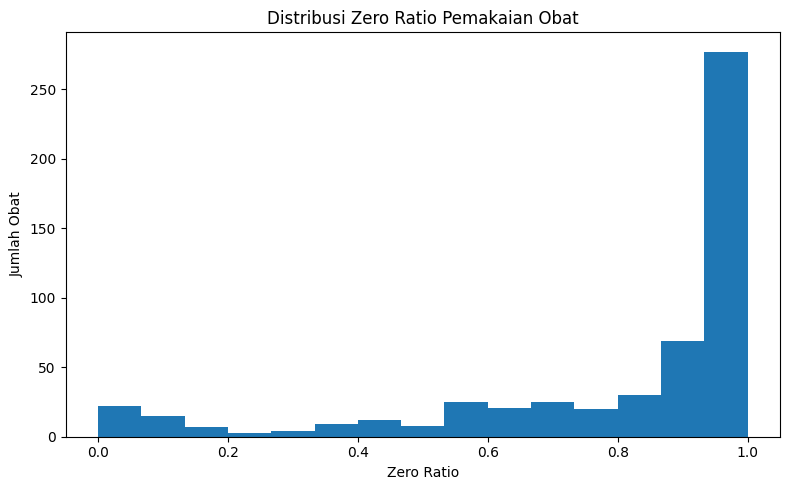

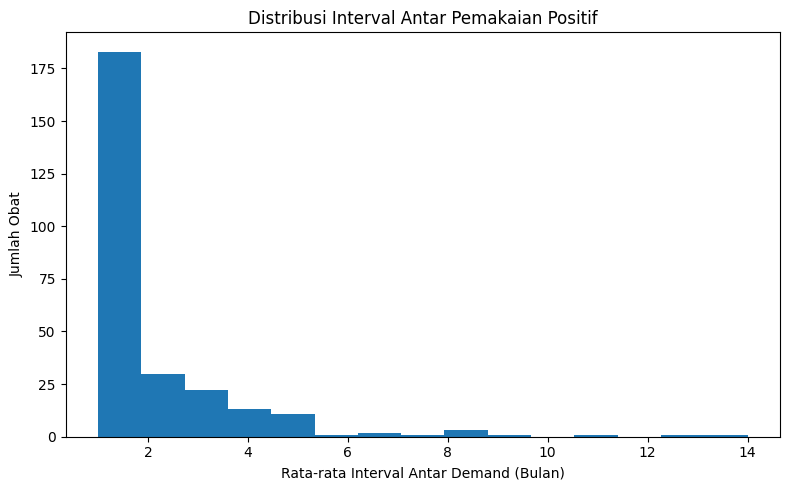

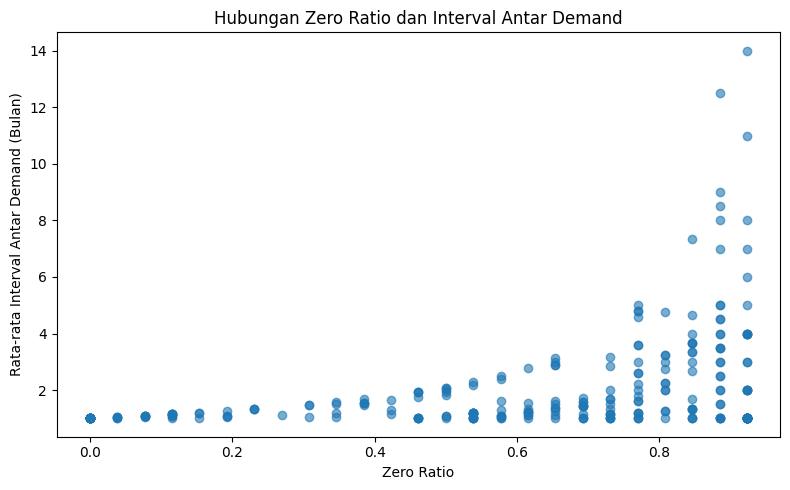


HASIL EDA INTERMITTENT DEMAND
Jumlah obat unik       : 547
Cenderung intermittent : 526 (96.16%)
Cenderung kontinu      : 21 (3.84%)
Rata-rata Zero Ratio   : 0.806
Median Zero Ratio      : 0.962
Rata-rata interval     : 2.029 bulan

File output:
EDA_Intermittent_Demand.xlsx


In [ ]:
# ============================================================
# CONFIG
# ============================================================
IN_TIMESERIES = "master_timeseries.csv"

OUT_EXCEL = "EDA_Intermittent_Demand.xlsx"

# Threshold untuk interpretasi sederhana
ZERO_RATIO_THRESHOLD = 0.40

# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv(
    IN_TIMESERIES,
    parse_dates=["Periode"]
)

df = df.sort_values(
    ["Nama_Obat", "Satuan", "Periode"]
).reset_index(drop=True)

print("Ukuran dataset:", df.shape)
print("Jumlah obat unik:", df[["Nama_Obat", "Satuan"]].drop_duplicates().shape[0])


# ============================================================
# 2. FUNGSI ANALISIS PER OBAT
# ============================================================

def analyze_intermittent(group):

    group = group.sort_values("Periode").copy()

    values = group["Pemakaian"].astype(float).values
    periods = group["Periode"].values

    n = len(values)

    # --------------------------------------------------------
    # A. ZERO RATIO
    # --------------------------------------------------------

    zero_count = np.sum(values == 0)
    positive_count = np.sum(values > 0)

    zero_ratio = zero_count / n if n > 0 else np.nan
    positive_ratio = positive_count / n if n > 0 else np.nan

    # --------------------------------------------------------
    # B. INTER-DEMAND INTERVAL
    # --------------------------------------------------------
    # Mengukur jarak antar bulan dengan pemakaian > 0
    # Contoh:
    # Jan = 100
    # Feb = 0
    # Mar = 0
    # Apr = 50
    #
    # Jarak demand = 3 bulan
    # --------------------------------------------------------

    positive_indices = np.where(values > 0)[0]

    if len(positive_indices) >= 2:

        intervals = np.diff(positive_indices)

        avg_interval = np.mean(intervals)
        median_interval = np.median(intervals)
        max_interval = np.max(intervals)

    else:

        avg_interval = np.nan
        median_interval = np.nan
        max_interval = np.nan

    # --------------------------------------------------------
    # C. JUMLAH PERIODE DEMAND
    # --------------------------------------------------------

    demand_occurrences = len(positive_indices)

    # --------------------------------------------------------
    # D. ADAKAH POLA INTERMITTENT?
    # --------------------------------------------------------
    #
    # Rule sederhana untuk EDA:
    #
    # Zero Ratio >= 30%
    # ATAU
    # rata-rata interval demand > 1 bulan
    #
    # Ini BUKAN model forecasting.
    # Hanya klasifikasi eksploratif untuk melihat karakteristik data.
    # --------------------------------------------------------

    if (
        zero_ratio >= ZERO_RATIO_THRESHOLD
        or (
            not np.isnan(avg_interval)
            and avg_interval > 1
        )
    ):
        karakteristik = "Cenderung Intermittent"
    else:
        karakteristik = "Cenderung Kontinu"

    return pd.Series({
        "N_Bulan": n,
        "Jumlah_Demand_Positive": demand_occurrences,
        "Jumlah_Bulan_Nol": zero_count,
        "Zero_Ratio": zero_ratio,
        "Positive_Ratio": positive_ratio,
        "Rata2_Interval_Demand_Bulan": avg_interval,
        "Median_Interval_Demand_Bulan": median_interval,
        "Maks_Interval_Demand_Bulan": max_interval,
        "Karakteristik_Demand": karakteristik
    })

# ============================================================
# 3. ANALISIS SEMUA OBAT
# ============================================================

eda_obat = (
    df.groupby(
        ["Nama_Obat", "Satuan"],
        group_keys=False
    )
    .apply(analyze_intermittent)
    .reset_index()
)

print("\nDistribusi karakteristik demand:")
print(
    eda_obat["Karakteristik_Demand"]
    .value_counts()
)

# ============================================================
# 4. RINGKASAN DATASET
# ============================================================

jumlah_obat = eda_obat.shape[0]

jumlah_intermittent = (
    eda_obat["Karakteristik_Demand"]
    .eq("Cenderung Intermittent")
    .sum()
)
jumlah_kontinu = (
    eda_obat["Karakteristik_Demand"]
    .eq("Cenderung Kontinu")
    .sum()
)
ringkasan = pd.DataFrame({
    "Indikator": [
        "Jumlah baris dataset",
        "Jumlah kolom dataset",
        "Jumlah obat unik",
        "Jumlah obat cenderung intermittent",
        "Jumlah obat cenderung kontinu",
        "Persentase obat cenderung intermittent",
        "Rata-rata Zero Ratio",
        "Median Zero Ratio",
        "Rata-rata interval antar demand",
        "Median interval antar demand"
    ],
    "Nilai": [
        len(df),
        len(df.columns),
        jumlah_obat,
        jumlah_intermittent,
        jumlah_kontinu,
        jumlah_intermittent / jumlah_obat * 100,
        eda_obat["Zero_Ratio"].mean(),
        eda_obat["Zero_Ratio"].median(),
        eda_obat["Rata2_Interval_Demand_Bulan"].mean(),
        eda_obat["Median_Interval_Demand_Bulan"].median()
    ]
})

# ============================================================
# 5. DISTRIBUSI ZERO RATIO
# ============================================================

zero_ratio_summary = (
    eda_obat["Zero_Ratio"]
    .describe()
    .reset_index()
)
zero_ratio_summary.columns = [
    "Statistik",
    "Zero_Ratio"
]

# ============================================================
# 6. KELOMPOK ZERO RATIO
# ============================================================

def kategori_zero_ratio(x):
    if x == 0:
        return "Tidak ada nol"
    elif x < 0.25:
        return "<25%"
    elif x < 0.50:
        return "25%-<50%"
    elif x < 0.75:
        return "50%-<75%"
    else:
        return ">=75%"

eda_obat["Kategori_Zero_Ratio"] = (
    eda_obat["Zero_Ratio"]
    .apply(kategori_zero_ratio)
)
distribusi_zero = (
    eda_obat
    .groupby("Kategori_Zero_Ratio")
    .size()
    .reset_index(name="Jumlah_Obat")
)
distribusi_zero["Persentase"] = (
    distribusi_zero["Jumlah_Obat"]
    / jumlah_obat * 100
)

# ============================================================
# 7. INTERVAL DEMAND
# ============================================================

interval_summary = (
    eda_obat[
        "Rata2_Interval_Demand_Bulan"
    ]
    .describe()
    .reset_index()
)
interval_summary.columns = [
    "Statistik",
    "Interval_Demand_Bulan"
]

# ============================================================
# 8. SIMPAN KE EXCEL
# ============================================================

with pd.ExcelWriter(
    OUT_EXCEL,
    engine="openpyxl"
) as writer:
    ringkasan.to_excel(
        writer,
        sheet_name="Ringkasan",
        index=False
    )
    eda_obat.to_excel(
        writer,
        sheet_name="EDA_Per_Obat",
        index=False
    )
    distribusi_zero.to_excel(
        writer,
        sheet_name="Distribusi_Zero",
        index=False
    )
    zero_ratio_summary.to_excel(
        writer,
        sheet_name="Statistik_Zero",
        index=False
    )
    interval_summary.to_excel(
        writer,
        sheet_name="Statistik_Interval",
        index=False
    )

# ============================================================
# 9. GRAFIK 1 — DISTRIBUSI ZERO RATIO
# ============================================================

plt.figure(figsize=(8, 5))

plt.hist(
    eda_obat["Zero_Ratio"].dropna(),
    bins=15
)
plt.xlabel("Zero Ratio")
plt.ylabel("Jumlah Obat")
plt.title("Distribusi Zero Ratio Pemakaian Obat")
plt.tight_layout()

plt.savefig(
    "EDA_Distribusi_Zero_Ratio.png",
    dpi=300
)
plt.show()

# ============================================================
# 10. GRAFIK 2 — INTERVAL ANTAR DEMAND
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(
    eda_obat[
        "Rata2_Interval_Demand_Bulan"
    ].dropna(),
    bins=15
)
plt.xlabel(
    "Rata-rata Interval Antar Demand (Bulan)"
)
plt.ylabel("Jumlah Obat")
plt.title(
    "Distribusi Interval Antar Pemakaian Positif"
)
plt.tight_layout()
plt.savefig(
    "EDA_Interval_Demand.png",
    dpi=300
)
plt.show()

# ============================================================
# 11. GRAFIK 3 — ZERO RATIO VS INTERVAL DEMAND
# ============================================================

plt.figure(figsize=(8, 5))

plt.scatter(
    eda_obat["Zero_Ratio"],
    eda_obat["Rata2_Interval_Demand_Bulan"],
    alpha=0.6
)
plt.xlabel("Zero Ratio")
plt.ylabel(
    "Rata-rata Interval Antar Demand (Bulan)"
)
plt.title(
    "Hubungan Zero Ratio dan Interval Antar Demand"
)
plt.tight_layout()
plt.savefig(
    "EDA_ZeroRatio_vs_Interval.png",
    dpi=300
)
plt.show()

# ============================================================
# 12. OUTPUT UTAMA
# ============================================================

print("\n============================================")
print("HASIL EDA INTERMITTENT DEMAND")
print("============================================")

print(f"Jumlah obat unik       : {jumlah_obat}")
print(
    f"Cenderung intermittent : "
    f"{jumlah_intermittent} "
    f"({jumlah_intermittent / jumlah_obat * 100:.2f}%)"
)
print(
    f"Cenderung kontinu      : "
    f"{jumlah_kontinu} "
    f"({jumlah_kontinu / jumlah_obat * 100:.2f}%)"
)
print(
    f"Rata-rata Zero Ratio   : "
    f"{eda_obat['Zero_Ratio'].mean():.3f}"
)
print(
    f"Median Zero Ratio      : "
    f"{eda_obat['Zero_Ratio'].median():.3f}"
)
print(
    f"Rata-rata interval     : "
    f"{eda_obat['Rata2_Interval_Demand_Bulan'].mean():.3f} bulan"
)

print("\nFile output:")
print(OUT_EXCEL)

sorting data menjadi 3 kelompok --> pemakaian tinggi (prioritas), sedang, rendah

In [4]:
# ============================= CONFIG ======================================
IN_TIMESERIES = "master_timeseries.csv"
IN_MASTERLIST_FILTERED = "obat_master_list.xlsx"   # hasil isian manual Anda
USE_MANUAL_EXCLUDE = True     # set False kalau belum ada filter manual

THRESHOLD_PRIORITAS = 0.80    # kumulatif % pemakaian utk kelompok Prioritas
THRESHOLD_SEDANG = 0.95       # kumulatif % pemakaian utk kelompok Sedang

OUT_PATH = "klasifikasi_abc.xlsx"
# ============================================================================


def load_total_pemakaian(path=IN_TIMESERIES) -> pd.DataFrame:
    ts = pd.read_csv(path)
    total = (
        ts.groupby(["Nama_Obat", "Satuan"])["Pemakaian"]
        .sum()
        .reset_index()
        .rename(columns={"Pemakaian": "Total_Pemakaian"})
    )
    return total


def apply_manual_exclude(total: pd.DataFrame) -> pd.DataFrame:
    if not USE_MANUAL_EXCLUDE:
        return total
    filt = pd.read_excel(IN_MASTERLIST_FILTERED)
    exclude_col = [c for c in filt.columns if c.startswith("Exclude")][0]
    excluded_names = filt.loc[
        filt[exclude_col].astype(str).str.upper().str.strip() == "YES",
        ["Nama_Obat", "Satuan"]
    ]
    before = len(total)
    total = total.merge(excluded_names, on=["Nama_Obat", "Satuan"], how="left", indicator=True)
    total = total[total["_merge"] == "left_only"].drop(columns="_merge")
    print(f"Obat dikeluarkan via filter manual: {before - len(total)}")
    return total


def classify_abc(total: pd.DataFrame) -> pd.DataFrame:
    df = total.sort_values("Total_Pemakaian", ascending=False).reset_index(drop=True)
    grand_total = df["Total_Pemakaian"].sum()
    df["Pct_Pemakaian"] = df["Total_Pemakaian"] / grand_total
    df["Kumulatif_Pct"] = df["Pct_Pemakaian"].cumsum()

    def label(cum):
        if cum <= THRESHOLD_PRIORITAS:
            return "Prioritas (Tinggi)"
        elif cum <= THRESHOLD_SEDANG:
            return "Sedang"
        else:
            return "Rendah"

    df["Kelompok"] = df["Kumulatif_Pct"].apply(label)
    df.insert(0, "Rank", range(1, len(df) + 1))
    return df


def summarize(df: pd.DataFrame) -> pd.DataFrame:
    ring = (
        df.groupby("Kelompok")
        .agg(Jumlah_Obat=("Nama_Obat", "count"),
             Total_Pemakaian=("Total_Pemakaian", "sum"))
        .reset_index()
    )
    ring["Pct_Jumlah_Obat"] = ring["Jumlah_Obat"] / ring["Jumlah_Obat"].sum() * 100
    ring["Pct_Total_Pemakaian"] = ring["Total_Pemakaian"] / ring["Total_Pemakaian"].sum() * 100
    order = {"Prioritas (Tinggi)": 0, "Sedang": 1, "Rendah": 2}
    ring = ring.sort_values("Kelompok", key=lambda s: s.map(order)).reset_index(drop=True)
    return ring


def run():
    total = load_total_pemakaian()
    total = apply_manual_exclude(total)
    classified = classify_abc(total)
    ringkasan = summarize(classified)

    with pd.ExcelWriter(OUT_PATH, engine="openpyxl") as writer:
        classified.to_excel(writer, sheet_name="Klasifikasi", index=False)
        ringkasan.to_excel(writer, sheet_name="Ringkasan", index=False)

    print(ringkasan.to_string(index=False))
    print(f"-> {OUT_PATH}")
    return classified


if __name__ == "__main__":
    run()


Obat dikeluarkan via filter manual: 0
          Kelompok  Jumlah_Obat  Total_Pemakaian  Pct_Jumlah_Obat  Pct_Total_Pemakaian
Prioritas (Tinggi)           27          1519453         4.936015            79.311878
            Sedang           36           299722         6.581353            15.644785
            Rendah          484            96620        88.482633             5.043337
-> klasifikasi_abc.xlsx


forecasting

In [ ]:
# ============================= CONFIG ======================================
IN_TIMESERIES = "master_timeseries.csv"
IN_MASTERLIST_FILTERED = "obat_master_list.xlsx"
IN_KLASIFIKASI = "klasifikasi_abc.xlsx"
USE_MANUAL_EXCLUDE = True

SEASONAL_PERIODS = 12
FORECAST_HORIZON = 3
PRIMARY_METRIC = "MAE"          # dasar pemilihan metode terbaik per obat
ALPHA_GRID = np.arange(0.05, 0.35, 0.05)   # kandidat alpha utk Croston/SBA

OUT_PATH = "combination_forecast_results.xlsx"
METHOD_NAMES = ["SES", "HW", "Croston", "SBA", "TSB", "Naive", "SMA3"]
METRIC_NAMES = ["MAE", "RMSE", "MAPE", "WMAPE"]
# ============================================================================


def load_series() -> pd.DataFrame:
    ts = pd.read_csv(IN_TIMESERIES, parse_dates=["Periode"])
    if USE_MANUAL_EXCLUDE:
        filt = pd.read_excel(IN_MASTERLIST_FILTERED)
        exclude_col = [c for c in filt.columns if c.startswith("Exclude")][0]
        excluded = filt.loc[
            filt[exclude_col].astype(str).str.upper().str.strip() == "YES",
            ["Nama_Obat", "Satuan"]
        ]
        before = ts[["Nama_Obat", "Satuan"]].drop_duplicates().shape[0]
        ts = ts.merge(excluded, on=["Nama_Obat", "Satuan"], how="left", indicator=True)
        ts = ts[ts["_merge"] == "left_only"].drop(columns="_merge")
        after = ts[["Nama_Obat", "Satuan"]].drop_duplicates().shape[0]
        print(f"Obat dikeluarkan via filter manual: {before - after}")
    return ts.sort_values(["Nama_Obat", "Satuan", "Periode"])


def train_test_split_len(n: int):
    if n < 7:
        return n, 0
    test_len = min(3, n - 6)
    return n - test_len, test_len


def zero_ratio(values: np.ndarray) -> float:
    return float(np.mean(values == 0))


# ============================================================================
# 7 METODE FORECASTING
# ============================================================================

def fit_ses(train):
    return SimpleExpSmoothing(train, initialization_method="estimated").fit(optimized=True)


def fit_hw(train, seasonal_periods=SEASONAL_PERIODS):
    n = len(train)
    if n < seasonal_periods:
        raise ValueError("data latih blm cukup utk 1 siklus musiman penuh")
    first_cycle = train[:seasonal_periods]
    initial_seasonal = first_cycle - first_cycle.mean()
    initial_level = first_cycle.mean()
    initial_trend = (train[seasonal_periods:].mean() - first_cycle.mean()) / seasonal_periods if n > seasonal_periods else 0.0
    return ExponentialSmoothing(
        train, trend="add", seasonal="add", seasonal_periods=seasonal_periods,
        initialization_method="known", initial_level=initial_level,
        initial_trend=initial_trend, initial_seasonal=initial_seasonal,
    ).fit(optimized=True)


def _croston_fitted_series(train, alpha):
    n = len(train)
    fitted = np.zeros(n)
    nz = np.nonzero(train)[0]
    if len(nz) == 0:
        return fitted, 0.0, 1.0
    fi = nz[0]
    z, q = train[fi], fi + 1
    cf = z / q
    fitted[fi] = cf
    li = fi
    for idx in nz[1:]:
        fitted[li + 1:idx] = cf
        interval = idx - li
        z = alpha * train[idx] + (1 - alpha) * z
        q = alpha * interval + (1 - alpha) * q
        cf = z / q
        fitted[idx] = cf
        li = idx
    fitted[li + 1:] = cf
    return fitted, z, q


def fit_croston_value(train, variant="classic", alpha_grid=ALPHA_GRID):
    best_alpha, best_mse, best_z, best_q = None, np.inf, None, None
    for alpha in alpha_grid:
        fitted, z, q = _croston_fitted_series(train, alpha)
        mse = np.mean((train - fitted) ** 2)
        if mse < best_mse:
            best_mse, best_alpha, best_z, best_q = mse, alpha, z, q
    val = best_z / best_q if best_q > 0 else 0.0
    if variant == "sba":
        val *= (1 - best_alpha / 2)
    return max(0.0, val), best_alpha


def fit_tsb_value(train, alpha=0.1, beta=0.1):
    """Teunter-Syntetos-Babai (2011): update probabilitas kejadian permintaan
    tiap periode (termasuk periode nol) -> lebih adaptif thd obat yang
    berhenti dipakai (obsolescence), tdk seperti Croston yg cuma update
    saat ada kejadian non-nol saja."""
    n = len(train)
    nz = np.nonzero(train)[0]
    if len(nz) == 0:
        return 0.0
    p = 1.0 / (nz[0] + 1)
    z = train[nz[0]]
    for t in range(n):
        occurred = train[t] > 0
        p = alpha * occurred + (1 - alpha) * p
        if occurred:
            z = beta * train[t] + (1 - beta) * z
    return max(0.0, p * z)


def fit_naive_value(train):
    return max(0.0, train[-1])


def fit_sma_value(train, k=3):
    return max(0.0, train[-min(k, len(train)):].mean())


# ============================================================================
# METRIK EVALUASI
# ============================================================================

def mae(actual, pred):
    return float(np.mean(np.abs(np.asarray(actual) - np.asarray(pred))))


def rmse(actual, pred):
    a, p = np.asarray(actual), np.asarray(pred)
    return float(np.sqrt(np.mean((a - p) ** 2)))


def mape(actual, pred):
    a, p = np.asarray(actual), np.asarray(pred)
    mask = a != 0
    if np.sum(mask) == 0:
        return np.nan
    return float(np.mean(np.abs((a[mask] - p[mask]) / a[mask])) * 100)


def wmape(actual, pred):
    a, p = np.asarray(actual), np.asarray(pred)
    denom = np.sum(np.abs(a))
    return float(np.sum(np.abs(a - p)) / denom * 100) if denom > 0 else np.nan


def all_metrics(actual, pred):
    return {"MAE": mae(actual, pred), "RMSE": rmse(actual, pred),
            "MAPE": mape(actual, pred), "WMAPE": wmape(actual, pred)}


# ============================================================================
# FIT SEMUA METODE & FORECAST HORIZON KE DEPAN (dipakai setelah model terpilih)
# ============================================================================

def forecast_with_method(method: str, full_data: np.ndarray, horizon: int) -> np.ndarray:
    if method == "SES":
        m = fit_ses(full_data)
        return np.asarray(m.forecast(horizon))
    elif method == "HW":
        m = fit_hw(full_data)
        return np.asarray(m.forecast(horizon))
    elif method == "Croston":
        val, _ = fit_croston_value(full_data, "classic")
        return np.full(horizon, val)
    elif method == "SBA":
        val, _ = fit_croston_value(full_data, "sba")
        return np.full(horizon, val)
    elif method == "TSB":
        val = fit_tsb_value(full_data)
        return np.full(horizon, val)
    elif method == "Naive":
        val = fit_naive_value(full_data)
        return np.full(horizon, val)
    elif method == "SMA3":
        val = fit_sma_value(full_data, 3)
        return np.full(horizon, val)
    else:
        raise ValueError(f"Metode tidak dikenal: {method}")


def _fit_and_score(method: str, train: np.ndarray, test: np.ndarray, test_len: int):
    """Fit 1 metode ke train, evaluasi ke test, kembalikan dict 4 metrik (atau None kalau gagal)."""
    try:
        if method == "SES":
            m = fit_ses(train); pred = m.forecast(test_len)
        elif method == "HW":
            m = fit_hw(train); pred = m.forecast(test_len)
        elif method == "Croston":
            val, _ = fit_croston_value(train, "classic"); pred = np.full(test_len, val)
        elif method == "SBA":
            val, _ = fit_croston_value(train, "sba"); pred = np.full(test_len, val)
        elif method == "TSB":
            val = fit_tsb_value(train); pred = np.full(test_len, val)
        elif method == "Naive":
            val = fit_naive_value(train); pred = np.full(test_len, val)
        elif method == "SMA3":
            val = fit_sma_value(train, 3); pred = np.full(test_len, val)
        else:
            return None
        return all_metrics(test, pred)
    except Exception:
        return None


def decide_and_forecast(nama, satuan, df_obat: pd.DataFrame):
    df_obat = df_obat.sort_values("Periode")
    values = df_obat["Pemakaian"].values.astype(float)
    n_total = len(values)
    n_bulan_ada_laporan = int(df_obat["Ada_Laporan"].sum())
    zratio = zero_ratio(values)
    train_len, test_len = train_test_split_len(n_total)

    result = {
        "Nama_Obat": nama, "Satuan": satuan,
        "N_Bulan_Total": n_total, "N_Bulan_Ada_Laporan": n_bulan_ada_laporan,
        "Zero_Ratio": round(zratio, 3),
        "Train_Len": train_len, "Test_Len": test_len,
    }
    # siapkan kolom MAE/RMSE/MAPE/WMAPE utk SEMUA 7 metode, default None
    for m in METHOD_NAMES:
        for met in METRIC_NAMES:
            result[f"{met}_{m}"] = None

    # ---------- data < 7 bulan -> tak bisa split, langsung Naive (metode paling aman) ----------
    if test_len == 0:
        result["Model_Terpilih"] = "Naive"
        result["Alasan"] = "Data < 7 bulan (tak cukup utk split train/test) -> gunakan Naive"
        forecast = forecast_with_method("Naive", values, FORECAST_HORIZON)
        for i, f in enumerate(forecast, start=1):
            result[f"Forecast_Bulan_{i}"] = max(0, round(float(f), 1))
        return result

    # ---------- fit ke-7 metode pada train, evaluasi pada test (SEMUA metrik disimpan) ----------
    train, test = values[:train_len], values[train_len:]
    scores = {}  # utk pemilihan model, pakai PRIMARY_METRIC

    for m in METHOD_NAMES:
        met_dict = _fit_and_score(m, train, test, test_len)
        if met_dict is not None:
            for met in METRIC_NAMES:
                result[f"{met}_{m}"] = met_dict[met]
            scores[m] = met_dict[PRIMARY_METRIC]

    if not scores:
        result["Model_Terpilih"] = "Naive (fallback)"
        result["Alasan"] = "Seluruh metode gagal di-fit"
        forecast = np.full(FORECAST_HORIZON, values[-1] if n_total > 0 else 0)
    else:
        best_method = min(scores, key=scores.get)
        result["Model_Terpilih"] = best_method
        result["Alasan"] = f"{PRIMARY_METRIC} terkecil di antara {len(scores)} metode ({best_method}={scores[best_method]:.3f})"
        forecast = forecast_with_method(best_method, values, FORECAST_HORIZON)

    for i, f in enumerate(forecast, start=1):
        result[f"Forecast_Bulan_{i}"] = max(0, round(float(f), 1))

    return result


def build_per_kelompok_sheet(result_df: pd.DataFrame) -> pd.DataFrame:
    klas = pd.read_excel(IN_KLASIFIKASI, sheet_name="Klasifikasi")[
        ["Nama_Obat", "Satuan", "Total_Pemakaian", "Pct_Pemakaian", "Kelompok"]
    ]
    merged = klas.merge(result_df, on=["Nama_Obat", "Satuan"], how="left")
    metric_cols = [f"{met}_{m}" for m in METHOD_NAMES for met in METRIC_NAMES]
    forecast_cols = [c for c in merged.columns if c.startswith("Forecast_Bulan")]
    cols = (["Kelompok", "Nama_Obat", "Satuan", "Total_Pemakaian", "Pct_Pemakaian",
              "Model_Terpilih", "Alasan"] + metric_cols + forecast_cols)
    order = {"Prioritas (Tinggi)": 0, "Sedang": 1, "Rendah": 2}
    merged["_ord"] = merged["Kelompok"].map(order)
    merged = merged.sort_values(["_ord", "Total_Pemakaian"], ascending=[True, False]).drop(columns="_ord")
    return merged[cols]


def build_ringkasan_kelompok(per_kelompok: pd.DataFrame) -> pd.DataFrame:
    """Ringkasan lengkap per kelompok: jumlah obat per metode terpilih,
    DITAMBAH rata-rata MAE/RMSE/MAPE/WMAPE utk KESELURUHAN 7 metode
    (bukan cuma metode yg terpilih), supaya bisa dibandingkan lengkap."""
    agg_dict = {"Jumlah_Obat": ("Nama_Obat", "count")}
    for m in METHOD_NAMES:
        agg_dict[f"Jumlah_Pakai_{m}"] = ("Model_Terpilih", lambda s, m=m: (s == m).sum())
    for m in METHOD_NAMES:
        for met in METRIC_NAMES:
            col = f"{met}_{m}"
            agg_dict[f"Rata2_{col}"] = (col, "mean")

    ring = per_kelompok.groupby("Kelompok").agg(**agg_dict).reset_index()
    order = {"Prioritas (Tinggi)": 0, "Sedang": 1, "Rendah": 2}
    ring = ring.sort_values("Kelompok", key=lambda s: s.map(order)).reset_index(drop=True)

    # urutkan kolom: info dasar -> jumlah pakai per metode -> rata2 metrik dikelompokkan per metode
    base_cols = ["Kelompok", "Jumlah_Obat"] + [f"Jumlah_Pakai_{m}" for m in METHOD_NAMES]
    metric_cols_ordered = []
    for m in METHOD_NAMES:
        for met in METRIC_NAMES:
            metric_cols_ordered.append(f"Rata2_{met}_{m}")
    return ring[base_cols + metric_cols_ordered]


def run():
    ts = load_series()
    results = []
    for (nama, satuan), grp in ts.groupby(["Nama_Obat", "Satuan"]):
        res = decide_and_forecast(nama, satuan, grp)
        results.append(res)
        print(f"{nama[:40]:40s} | {satuan:12s} | {res['Model_Terpilih']:10s} | {res['Alasan']}")

    result_df = pd.DataFrame(results)

    metric_cols = [f"{met}_{m}" for m in METHOD_NAMES for met in METRIC_NAMES]
    forecast_cols = [c for c in result_df.columns if c.startswith("Forecast_Bulan")]
    detail_cols = ["Nama_Obat", "Satuan", "N_Bulan_Total", "N_Bulan_Ada_Laporan",
                   "Zero_Ratio", "Train_Len", "Test_Len"]
    main_cols = ["Nama_Obat", "Satuan", "Model_Terpilih", "Alasan"] + metric_cols + forecast_cols

    per_kelompok = build_per_kelompok_sheet(result_df)
    ringkasan_kelompok = build_ringkasan_kelompok(per_kelompok)

    with pd.ExcelWriter(OUT_PATH, engine="openpyxl") as writer:
        result_df[main_cols].to_excel(writer, sheet_name="Forecast", index=False)
        per_kelompok.to_excel(writer, sheet_name="Per_Kelompok", index=False)
        ringkasan_kelompok.to_excel(writer, sheet_name="Ringkasan_Kelompok", index=False)
        result_df[detail_cols].to_excel(writer, sheet_name="Detail_Uji", index=False)

    print("\nRingkasan pemilihan metode (semua obat):")
    print(result_df["Model_Terpilih"].value_counts())
    print(f"-> {OUT_PATH}")


if __name__ == "__main__":
    run()

Obat dikeluarkan via filter manual: 0
ATS Biosat                               | Ampul        | Naive      | MAE terkecil di antara 7 metode (Naive=0.000)
Acarbose 50 mg                           | Tablet       | Naive      | MAE terkecil di antara 7 metode (Naive=0.000)
Acetylcystein 200 mg                     | Tablet       | Naive      | MAE terkecil di antara 7 metode (Naive=0.000)
Acyclovir 200 mg tab                     | Tidak Diketahui | SES        | MAE terkecil di antara 7 metode (SES=0.000)
Acyclovir 400 mg                         | Tablet       | SMA3       | MAE terkecil di antara 7 metode (SMA3=765.556)
Acyclovir 5% cream                       | Tube         | SES        | MAE terkecil di antara 7 metode (SES=5.188)
Alanin Transmirase (ALTL) cobas          | Tidak Diketahui | SES        | MAE terkecil di antara 7 metode (SES=0.000)
Albendazol 200 mg/5 ml susp              | Botol        | Naive      | MAE terkecil di antara 7 metode (Naive=0.000)
Albendazol syrup         

justifikasi (cv & zero ratio)

In [ ]:
# ============================= CONFIG ======================================
IN_TIMESERIES = "master_timeseries.csv"
IN_MASTERLIST_FILTERED = "obat_master_list.xlsx"
USE_MANUAL_EXCLUDE = True
IN_FORECAST_RESULTS = "combination_forecast_results.xlsx"   # hasil 7 metode

METHOD_NAMES = ["SES", "HW", "Croston", "SBA", "TSB", "Naive", "SMA3"]
CV_THRESHOLD = 1.0     # rule of thumb: CV > 1 -> variabilitas tinggi

OUT_PATH = "justifikasi_kualitas_data.xlsx"
# ============================================================================


def load_series() -> pd.DataFrame:
    ts = pd.read_csv(IN_TIMESERIES, parse_dates=["Periode"])
    if USE_MANUAL_EXCLUDE:
        filt = pd.read_excel(IN_MASTERLIST_FILTERED)
        exclude_col = [c for c in filt.columns if c.startswith("Exclude")][0]
        excluded = filt.loc[
            filt[exclude_col].astype(str).str.upper().str.strip() == "YES",
            ["Nama_Obat", "Satuan"]
        ]
        ts = ts.merge(excluded, on=["Nama_Obat", "Satuan"], how="left", indicator=True)
        ts = ts[ts["_merge"] == "left_only"].drop(columns="_merge")
    return ts.sort_values(["Nama_Obat", "Satuan", "Periode"])


def compute_cv_zero_ratio(values: np.ndarray):
    mean_val = values.mean()
    std_val = values.std(ddof=0)
    cv = (std_val / mean_val) if mean_val > 0 else np.nan
    zratio = float(np.mean(values == 0))
    return cv, zratio


def get_wmape_final(row):
    """Ambil WMAPE dari kolom sesuai Model_Terpilih obat itu (dinamis per baris)."""
    model = row["Model_Terpilih"]
    base_model = model.split(" ")[0] if model not in METHOD_NAMES else model
    col = f"WMAPE_{base_model}"
    return row[col] if col in row.index else np.nan


def uji_korelasi(data_df, x_col, y_col):
    sub = data_df[[x_col, y_col]].dropna()
    if len(sub) < 3:
        return {"Variabel_X": x_col, "Variabel_Y": y_col, "N": len(sub),
                "Pearson_r": None, "Pearson_p": None,
                "Spearman_r": None, "Spearman_p": None,
                "Kesimpulan": "Data tidak cukup utk uji korelasi"}
    r_p, p_p = pearsonr(sub[x_col], sub[y_col])
    r_s, p_s = spearmanr(sub[x_col], sub[y_col])
    if p_s < 0.05 and r_s > 0:
        kesimpulan = "Korelasi POSITIF signifikan -> makin tinggi X, makin tinggi error forecasting"
    elif p_s < 0.05 and r_s < 0:
        kesimpulan = "Korelasi NEGATIF signifikan"
    else:
        kesimpulan = "Tidak signifikan (p >= 0.05)"
    return {
        "Variabel_X": x_col, "Variabel_Y": y_col, "N": len(sub),
        "Pearson_r": round(r_p, 3), "Pearson_p": round(p_p, 4),
        "Spearman_r": round(r_s, 3), "Spearman_p": round(p_s, 4),
        "Kesimpulan": kesimpulan,
    }


def run():
    ts = load_series()

    rows = []
    for (nama, satuan), grp in ts.groupby(["Nama_Obat", "Satuan"]):
        values = grp.sort_values("Periode")["Pemakaian"].values.astype(float)
        cv, zratio = compute_cv_zero_ratio(values)
        rows.append({
            "Nama_Obat": nama, "Satuan": satuan,
            "N_Bulan": len(values),
            "CV": round(cv, 3) if not np.isnan(cv) else None,
            "Variabilitas": ("Tinggi (CV>1)" if (not np.isnan(cv) and cv > CV_THRESHOLD)
                              else ("Rendah (CV<=1)" if not np.isnan(cv) else "Tdk terdefinisi (rata2=0)")),
            "Zero_Ratio": round(zratio, 3),
        })
    data_df = pd.DataFrame(rows)

    # ---- gabung dgn hasil forecasting 7 metode ----
    wmape_cols = [f"WMAPE_{m}" for m in METHOD_NAMES]
    fc = pd.read_excel(IN_FORECAST_RESULTS, sheet_name="Forecast")[
        ["Nama_Obat", "Satuan", "Model_Terpilih"] + wmape_cols
    ]
    data_df = data_df.merge(fc, on=["Nama_Obat", "Satuan"], how="left")

    # ---- WMAPE_Final: ambil sesuai metode yg BENAR2 dipakai per obat ----
    data_df["WMAPE_Final"] = data_df.apply(get_wmape_final, axis=1)

    # ---- uji korelasi utama: CV & Zero_Ratio vs WMAPE_Final ----
    pasangan_utama = [("CV", "WMAPE_Final"), ("Zero_Ratio", "WMAPE_Final")]
    hasil_utama = pd.DataFrame([uji_korelasi(data_df, x, y) for x, y in pasangan_utama])

    # ---- uji korelasi pelengkap: CV & Zero_Ratio vs WMAPE tiap 1 dari 7 metode ----
    pasangan_pelengkap = [(x, f"WMAPE_{m}") for x in ["CV", "Zero_Ratio"] for m in METHOD_NAMES]
    hasil_pelengkap = pd.DataFrame([uji_korelasi(data_df, x, y) for x, y in pasangan_pelengkap])

    out_cols = ["Nama_Obat", "Satuan", "N_Bulan", "CV", "Variabilitas", "Zero_Ratio",
                "Model_Terpilih", "WMAPE_Final"] + wmape_cols

    with pd.ExcelWriter(OUT_PATH, engine="openpyxl") as writer:
        data_df[out_cols].to_excel(writer, sheet_name="Data_Per_Obat", index=False)
        hasil_utama.to_excel(writer, sheet_name="Hasil_Uji_Korelasi", index=False)
        hasil_pelengkap.to_excel(writer, sheet_name="Uji_Korelasi_per_Metode", index=False)

    print(data_df["Variabilitas"].value_counts())
    print()
    print("=== Hasil Uji Korelasi Utama (vs WMAPE model terpilih per obat) ===")
    print(hasil_utama.to_string(index=False))
    print(f"\n-> {OUT_PATH}")


if __name__ == "__main__":
    run()

Variabilitas
Tinggi (CV>1)                276
Tdk terdefinisi (rata2=0)    237
Rendah (CV<=1)                34
Name: count, dtype: int64

=== Hasil Uji Korelasi Utama (vs WMAPE model terpilih per obat) ===
Variabel_X  Variabel_Y   N  Pearson_r  Pearson_p  Spearman_r  Spearman_p                                                                    Kesimpulan
        CV WMAPE_Final 163      0.191     0.0146       0.631         0.0 Korelasi POSITIF signifikan -> makin tinggi X, makin tinggi error forecasting
Zero_Ratio WMAPE_Final 163      0.188     0.0163       0.548         0.0 Korelasi POSITIF signifikan -> makin tinggi X, makin tinggi error forecasting

-> justifikasi_kualitas_data.xlsx


strategi penyusunan stok obat (rasio kecukupan + buffer wmape)

In [ ]:
"""
================================================================================
STRATEGI PENYUSUNAN STOK OBAT BERBASIS FORECASTING (Rasio Kecukupan)
================================================================================
Tujuan:
  Menghubungkan hasil sorting (ABC/Pareto) dan forecasting (7 metode) secara
  KUANTITATIF ke dalam rekomendasi aksi replenishment per obat, sehingga
  forecasting benar-benar menjadi input keputusan strategi (bukan sekadar
  angka evaluasi yang berdiri sendiri terpisah dari ABC).

Input:
  1. combination_forecast_results.xlsx -> sheet "Per_Kelompok"
     (Kelompok ABC, Model_Terpilih, WMAPE per metode, Forecast_Bulan_1/2/3)
  2. LPLPO_CLEAN_2024-2026.xlsx -> sheet "Data_Lengkap"
     (dipakai untuk mengambil Sisa_Stok pada periode PELAPORAN TERAKHIR
      yang tersedia untuk tiap obat, sebagai proksi "stok aktual")

Logika inti:
  Forecast_3_Bulan   = Forecast_Bulan_1 + Forecast_Bulan_2 + Forecast_Bulan_3
  WMAPE_Final        = WMAPE dari model yang BENAR-BENAR terpilih per obat
                        (bukan rata-rata 7 metode -> dinamis per baris)
  Forecast_Terkoreksi = Forecast_3_Bulan x (1 + WMAPE_Final / 100)
                        -> obat dengan error tinggi diberi buffer lebih besar
  Rasio_Kecukupan     = Stok_Aktual / Forecast_Terkoreksi
                        <1 -> stok diperkirakan TIDAK cukup 3 bulan ke depan
                        >=1 -> stok diperkirakan masih cukup

  Rekomendasi_Aksi ditentukan dari kombinasi (Kelompok ABC x Rasio_Kecukupan)
  mengikuti matriks strategi (lihat MATRIKS_AKSI di bawah).

Output:
  strategi_stok_obat.xlsx dengan 4 sheet:
    - Strategi_Lengkap   : seluruh obat, siap dipakai sbg lampiran skripsi
    - Contoh_Prioritas   : 5 obat contoh kelompok Prioritas (utk Tabel Bab IV)
    - Contoh_Sedang      : 5 obat contoh kelompok Sedang
    - Contoh_Rendah      : 5 obat contoh kelompok Rendah
================================================================================
"""

import numpy as np
import pandas as pd

# ============================= CONFIG ======================================
IN_FORECAST_RESULTS = "combination_forecast_results.xlsx"
IN_LPLPO_CLEAN = "LPLPO_CLEAN_2024-2026.xlsx"

METHOD_NAMES = ["SES", "HW", "Croston", "SBA", "TSB", "Naive", "SMA3"]

OUT_PATH = "strategi_stok_obat.xlsx"
N_CONTOH_PER_KELOMPOK = 5
# ============================================================================


def get_wmape_final(row: pd.Series) -> float:
    """Ambil WMAPE dari kolom sesuai Model_Terpilih obat itu (dinamis per baris).
    Konsisten dengan fungsi yang sama di tahap uji korelasi CV/Zero_Ratio."""
    model = str(row["Model_Terpilih"]).strip()
    base_model = model.split(" ")[0] if model not in METHOD_NAMES else model
    col = f"WMAPE_{base_model}"
    val = row[col] if col in row.index else np.nan
    # WMAPE bisa kosong (obat tanpa pemakaian sama sekali -> pembagi 0)
    return val if pd.notna(val) else 0.0


def load_stok_terakhir() -> pd.DataFrame:
    """Ambil Sisa_Stok pada periode pelaporan TERAKHIR yang tersedia per obat,
    dipakai sebagai proksi 'Stok Aktual' (bukan hanya baris Feb 2026, karena
    tidak semua obat memiliki baris laporan pada bulan tersebut)."""
    df = pd.read_excel(IN_LPLPO_CLEAN, sheet_name="Data_Lengkap")
    df["Periode_Num"] = df["Tahun"] * 100 + df["Bulan"]
    idx = df.groupby(["Nama_Obat", "Satuan"])["Periode_Num"].idxmax()
    last_stock = df.loc[idx, ["Nama_Obat", "Satuan", "Periode_Num", "Sisa_Stok"]]
    last_stock = last_stock.rename(
        columns={"Sisa_Stok": "Stok_Aktual", "Periode_Num": "Periode_Stok_Terakhir"}
    )
    return last_stock


def label_rasio(kelompok: str, rasio: float) -> str:
    """Matriks aksi: kombinasi Kelompok ABC x Rasio Kecukupan.
    Ini bagian yang membuat forecasting benar-benar menentukan keputusan,
    bukan sekadar informasi tambahan di samping ABC."""
    kurang = rasio < 1.0

    if kelompok == "Prioritas (Tinggi)":
        if kurang:
            return "Replenishment SEGERA - prioritas pengadaan tertinggi"
        return "Stok cukup - monitoring ketat, belum perlu pengadaan"

    if kelompok == "Sedang":
        if kurang:
            return "Replenishment terjadwal - dalam siklus pengadaan berikutnya"
        return "Stok cukup - tunda pengadaan, evaluasi ulang bulan depan"

    # Rendah
    if kurang:
        return "Verifikasi kebutuhan klinis dulu sebelum replenishment"
    return "Stok cukup - tidak perlu tindakan, waspada risiko overstock"


def run() -> None:
    # ---- 1. Baca hasil forecasting per kelompok ABC ----
    fc = pd.read_excel(IN_FORECAST_RESULTS, sheet_name="Per_Kelompok")
    fc = fc.dropna(subset=["Nama_Obat"]).copy()

    fc["Forecast_3_Bulan"] = (
        fc["Forecast_Bulan_1"].fillna(0)
        + fc["Forecast_Bulan_2"].fillna(0)
        + fc["Forecast_Bulan_3"].fillna(0)
    )
    fc["WMAPE_Final"] = fc.apply(get_wmape_final, axis=1)

    # ---- 2. Gabungkan dengan stok aktual (periode pelaporan terakhir) ----
    stok = load_stok_terakhir()
    df = fc.merge(stok, on=["Nama_Obat", "Satuan"], how="left")
    df["Stok_Aktual"] = df["Stok_Aktual"].fillna(0)

    # ---- 3. Forecast terkoreksi + Rasio Kecukupan ----
    df["Forecast_Terkoreksi"] = df["Forecast_3_Bulan"] * (1 + df["WMAPE_Final"] / 100)

    # Hindari pembagian dengan 0: obat dgn forecast terkoreksi = 0 dianggap
    # "tidak ada indikasi kebutuhan" -> rasio diset sangat besar (dianggap cukup)
    df["Rasio_Kecukupan"] = np.where(
        df["Forecast_Terkoreksi"] > 0,
        df["Stok_Aktual"] / df["Forecast_Terkoreksi"],
        np.inf,
    )

    # ---- 4. Rekomendasi aksi (matriks ABC x Rasio Kecukupan) ----
    df["Rekomendasi_Aksi"] = df.apply(
        lambda r: label_rasio(r["Kelompok"], r["Rasio_Kecukupan"]), axis=1
    )

    # ---- 5. Susun kolom output ----
    out_cols = [
        "Kelompok", "Nama_Obat", "Satuan", "Model_Terpilih",
        "Forecast_3_Bulan", "WMAPE_Final", "Forecast_Terkoreksi",
        "Stok_Aktual", "Periode_Stok_Terakhir", "Rasio_Kecukupan",
        "Rekomendasi_Aksi",
    ]
    hasil = df[out_cols].copy()
    for c in ["Forecast_3_Bulan", "WMAPE_Final", "Forecast_Terkoreksi", "Rasio_Kecukupan"]:
        hasil[c] = hasil[c].round(2)

    order = {"Prioritas (Tinggi)": 0, "Sedang": 1, "Rendah": 2}
    hasil["_ord"] = hasil["Kelompok"].map(order)
    hasil = hasil.sort_values(["_ord", "Rasio_Kecukupan"]).drop(columns="_ord")

    # ---- 6. Contoh per kelompok (utk tabel Bab IV) ----
    def ambil_contoh(kelompok):
        sub = hasil[hasil["Kelompok"] == kelompok]
        # ambil variasi: beberapa dgn rasio<1 dan beberapa dgn rasio>=1 kalau ada
        kurang = sub[sub["Rasio_Kecukupan"] < 1].head(3)
        cukup = sub[sub["Rasio_Kecukupan"] >= 1].head(2)
        return pd.concat([kurang, cukup]).head(N_CONTOH_PER_KELOMPOK)

    contoh_prioritas = ambil_contoh("Prioritas (Tinggi)")
    contoh_sedang = ambil_contoh("Sedang")
    contoh_rendah = ambil_contoh("Rendah")

    # ---- 7. Simpan ----
    with pd.ExcelWriter(OUT_PATH, engine="openpyxl") as writer:
        hasil.to_excel(writer, sheet_name="Strategi_Lengkap", index=False)
        contoh_prioritas.to_excel(writer, sheet_name="Contoh_Prioritas", index=False)
        contoh_sedang.to_excel(writer, sheet_name="Contoh_Sedang", index=False)
        contoh_rendah.to_excel(writer, sheet_name="Contoh_Rendah", index=False)

    print("Ringkasan Rekomendasi Aksi per Kelompok:")
    print(hasil.groupby(["Kelompok", "Rekomendasi_Aksi"]).size().to_string())
    print(f"\n-> {OUT_PATH}")


if __name__ == "__main__":
    run()
